In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('data_science_job.csv')

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [9]:
df.isnull().mean()*100
#viewing missing data percentage

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [10]:
#taking cols where 5% or less missing data
cols=[col for col in df.columns if df[col].isnull().mean()<0.05 and df[col].isnull().mean()>0]

In [11]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [12]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
4918,0.910,no_enrollment,Graduate,20.0,280.0
12622,0.926,no_enrollment,Graduate,3.0,40.0
18242,0.550,no_enrollment,Graduate,5.0,146.0
4100,0.698,Part time course,High School,11.0,32.0
11095,0.910,no_enrollment,Graduate,19.0,18.0


In [13]:
#dropping missing rows
new_df=df[cols].dropna()

In [15]:
df.shape,new_df.shape

((19158, 13), (17182, 5))

<h1>Visualising Before/After CCA</h1>

<h3>Numerical Datas</h3>

<p>We see that if there is no significant change in the distribution then the data was MCAR.</p>

Text(0.5, 1.0, 'After CCA')

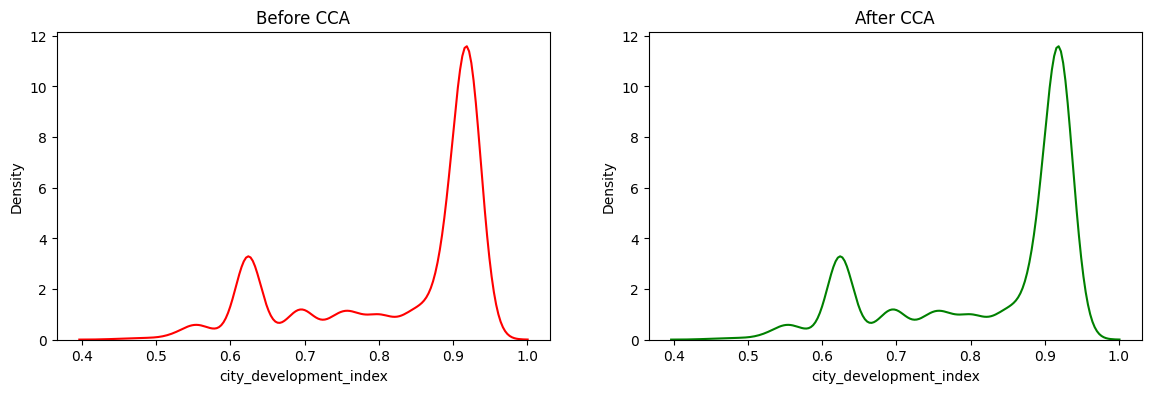

In [27]:
#city_development_index
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))

sns.kdeplot(df['city_development_index'],color='red',ax=ax1)
ax1.set_title('Before CCA')

sns.kdeplot(df['city_development_index'],color='green',ax=ax2)
ax2.set_title('After CCA')

Text(0.5, 1.0, 'After CCA')

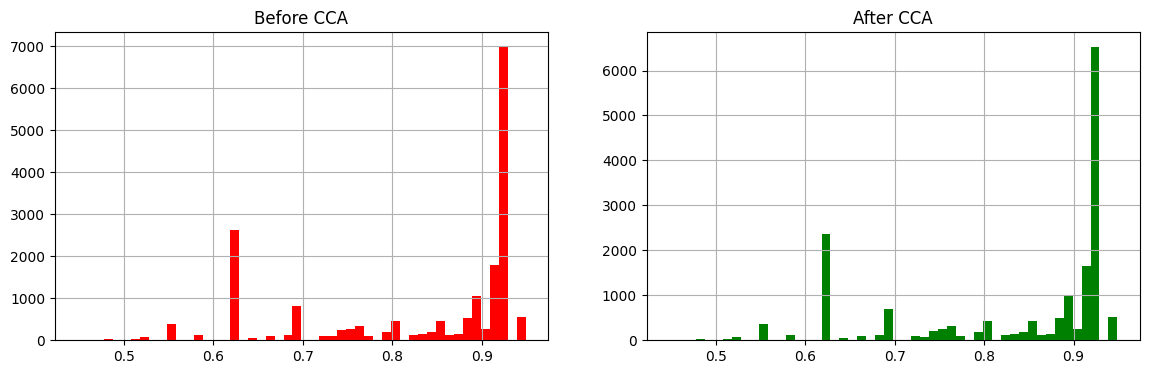

In [28]:
#city_development_index
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
df['city_development_index'].hist(bins=50,color='red',ax=ax1)
ax1.set_title('Before CCA')

new_df['city_development_index'].hist(bins=50,color='green',ax=ax2)
ax2.set_title('After CCA')

Text(0.5, 1.0, 'After CCA')

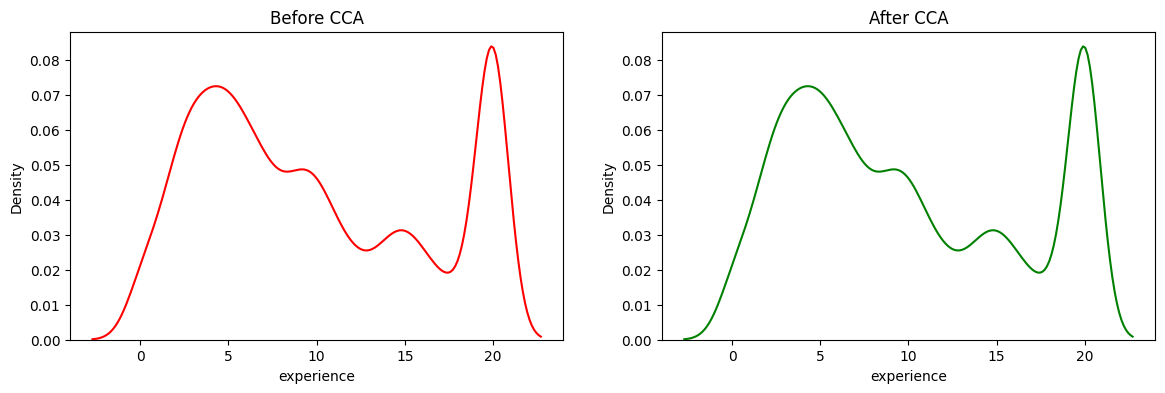

In [30]:
#experience

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))

sns.kdeplot(df['experience'],color='red',ax=ax1)
ax1.set_title('Before CCA')

sns.kdeplot(df['experience'],color='green',ax=ax2)
ax2.set_title('After CCA')

Text(0.5, 1.0, 'After CCA')

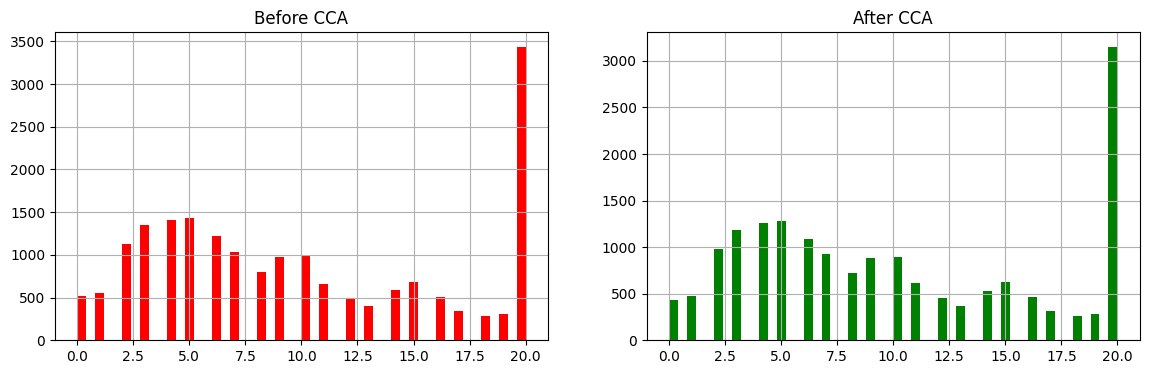

In [31]:
#experience

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
df['experience'].hist(bins=50,color='red',ax=ax1)
ax1.set_title('Before CCA')

new_df['experience'].hist(bins=50,color='green',ax=ax2)
ax2.set_title('After CCA')

Text(0.5, 1.0, 'After CCA')

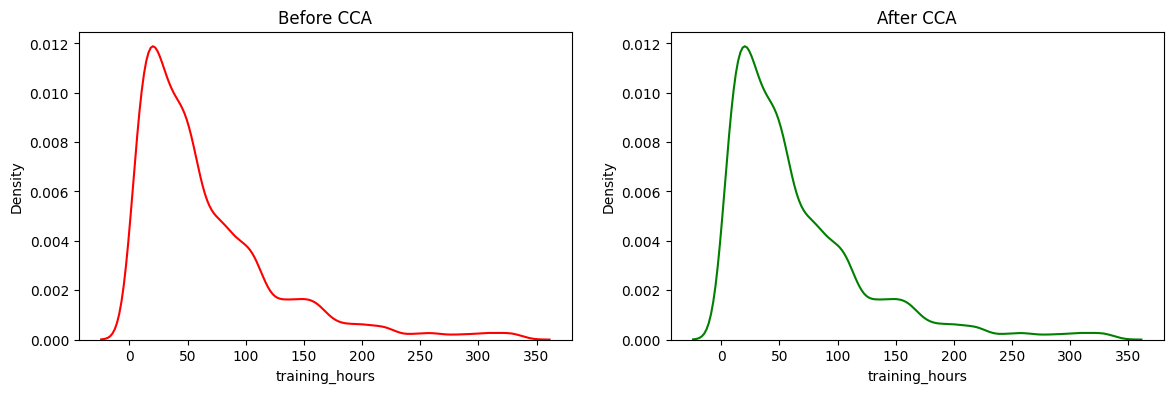

In [32]:
#training_hours

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))

sns.kdeplot(df['training_hours'],color='red',ax=ax1)
ax1.set_title('Before CCA')

sns.kdeplot(df['training_hours'],color='green',ax=ax2)
ax2.set_title('After CCA')

Text(0.5, 1.0, 'After CCA')

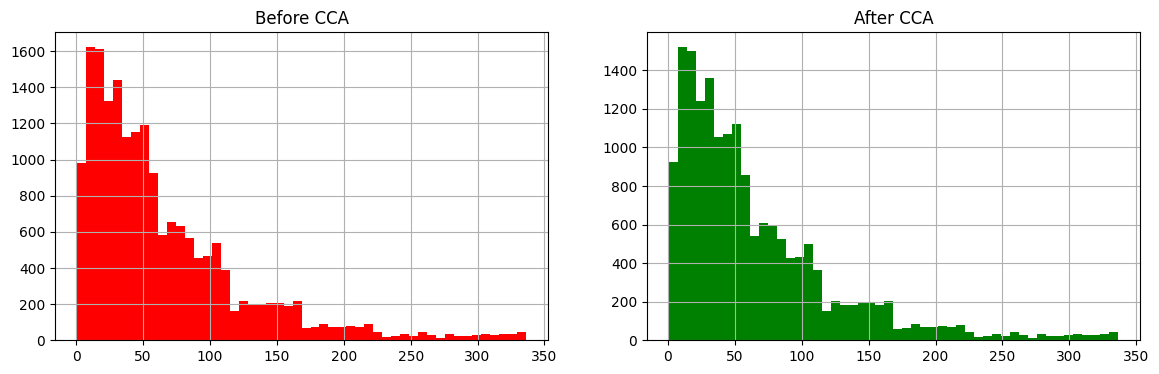

In [33]:
#training_hours

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
df['training_hours'].hist(bins=50,color='red',ax=ax1)
ax1.set_title('Before CCA')

new_df['training_hours'].hist(bins=50,color='green',ax=ax2)
ax2.set_title('After CCA')

<h3>Categorical Datas</h3>

<p>We check for the ratio of observation per category to the original data and cca data and if there is no significant difference we can say that the data was MCAR. </p>

In [36]:
#enrolled_university

temp=pd.concat([
            df['enrolled_university'].value_counts()/len(df),
            new_df['enrolled_university'].value_counts()/len(new_df)
        ],axis=1)

temp.columns=['original','cca']

In [37]:
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [38]:
#education_level

temp=pd.concat([
            df['education_level'].value_counts()/len(df),
            new_df['education_level'].value_counts()/len(new_df)
     ],axis=1)

temp.columns=['original','cca']

In [39]:
temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
